# Regression model to predict the cost of an airplane flight

## Importing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

## Loading Processed Data

In [2]:
data = joblib.load("../data/processed/train_test_data.joblib")

In [3]:
X_train = data["X_train"]
X_test= data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

In [4]:
X_train.head()

,departure_time,stops,arrival_time,class,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0.0,0.5,0.8,1.0,0.339301,0.270833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.4,0.5,0.2,0.0,0.385550,0.645833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.2,0.0,0.4,0.0,0.014280,0.895833,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.5,0.2,0.0,0.547101,0.375000,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.5,0.4,0.0,0.184783,0.250000,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Model

In [5]:
base_model = LinearRegression()

## Training

In [6]:
base_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluating

In [7]:
y_train_pred = base_model.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Error Cuadrático Medio (MSE): {mse_train:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_train:.2f}")

Error Cuadrático Medio (MSE): 46524787.30
Coeficiente de Determinación (R²): 0.91


## Visualizing

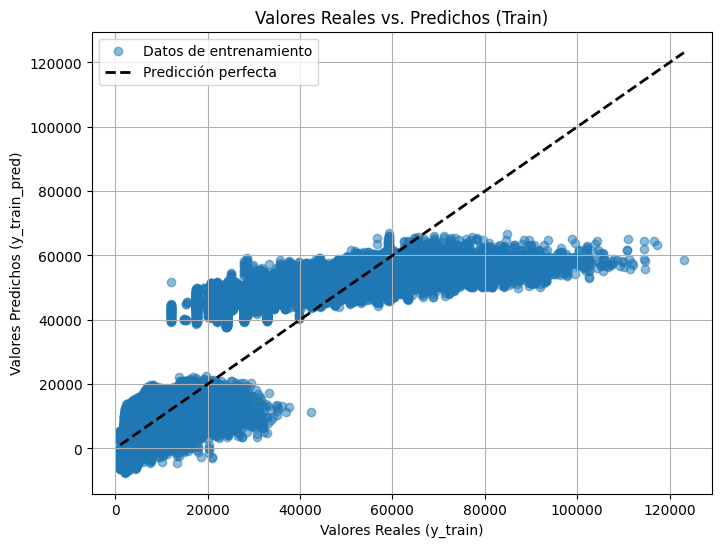

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, alpha=0.5, label='Datos de entrenamiento')  # Usando y_train y y_train_pred
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2, label='Predicción perfecta')  # Línea ideal
plt.xlabel('Valores Reales (y_train)')
plt.ylabel('Valores Predichos (y_train_pred)')
plt.title('Valores Reales vs. Predichos (Train)')
plt.legend()
plt.grid(True)